In [1]:
# constructive_tanh_barycentric.py
from __future__ import annotations
import numpy as np
import jax
import jax.numpy as jnp
from flax import nnx
import matplotlib.pyplot as plt

# ----- FP64
jax.config.update("jax_enable_x64", True)
DTYPE = jnp.float64


# =========================
# Chebyshev tools (Lobatto)
# =========================
def cheb_lobatto_nodes(K: int) -> jnp.ndarray:
    """Nodes x_j = cos(pi * j / K), j=0..K (Chebyshev 'second kind' / Lobatto)."""
    j = jnp.arange(K + 1, dtype=DTYPE)
    return jnp.cos(jnp.pi * j / K)


def cheb_vandermonde(x: jnp.ndarray, K: int) -> jnp.ndarray:
    """A[j,k] = T_k(x_j), k=0..K, via recurrence."""
    x = x.astype(DTYPE)
    n = x.shape[0]
    A = jnp.zeros((n, K + 1), dtype=DTYPE)
    if K >= 0: A = A.at[:, 0].set(1.0)
    if K >= 1: A = A.at[:, 1].set(x)
    if K >= 2:
        def body(carry, k):
            Tkm1, Tk = carry
            Tkp1 = 2.0 * x * Tk - Tkm1
            return (Tk, Tkp1), Tkp1
        (_, _), seq = jax.lax.scan(body, (A[:,0], A[:,1]), jnp.arange(1, K))
        A = A.at[:, 2:].set(seq.T)
    return A


def cheb_monomial_coeffs(K: int) -> jnp.ndarray:
    """C[k,p] s.t. T_k(x) = sum_{p=0}^k C[k,p] x^p."""
    C = np.zeros((K + 1, K + 1), dtype=np.float64)
    C[0,0] = 1.0
    if K >= 1: C[1,1] = 1.0
    for k in range(1, K):
        Tk, Tkm1 = C[k], C[k-1]
        two_x_Tk = np.zeros(K + 1, dtype=np.float64)
        two_x_Tk[1:] = 2.0 * Tk[:-1]
        C[k+1] = two_x_Tk - Tkm1
    return jnp.asarray(C, dtype=DTYPE)


# ==============================================
# Barycentric (2nd form) at Chebyshev–Lobatto
# ==============================================
def lobatto_bary_weights(K: int) -> jnp.ndarray:
    """
    Barycentric weights for Lobatto nodes x_j = cos(pi j / K), j=0..K:
      w_0 = w_K = 1/2, others = 1, with alternating signs (-1)^j.
    Only relative weights matter in 2nd form.
    """
    j = jnp.arange(K + 1, dtype=DTYPE)
    w = jnp.ones((K + 1,), dtype=DTYPE)
    w = w.at[0].set(0.5).at[-1].set(0.5)
    w = w * ((-1.0) ** j)
    return w


def barycentric_eval_lobatto(x_nodes: jnp.ndarray,
                             y_nodes: jnp.ndarray,
                             x_eval: jnp.ndarray) -> jnp.ndarray:
    """Second barycentric formula at Lobatto nodes x_nodes with weights from above."""
    K = x_nodes.shape[0] - 1
    w = lobatto_bary_weights(K)  # (K+1,)
    x_eval = jnp.asarray(x_eval, dtype=DTYPE)
    x_nodes = x_nodes.astype(DTYPE); y_nodes = y_nodes.astype(DTYPE)

    def one_point(x):
        # If x equals a node: return exact y_j
        diffs = x - x_nodes
        idx = jnp.argmin(jnp.abs(diffs))
        return jnp.where(jnp.isclose(diffs[idx], 0.0),
                         y_nodes[idx],
                         (jnp.sum(w * y_nodes / diffs) / jnp.sum(w / diffs)))
    return jax.vmap(one_point)(x_eval)


# ======================================
# Get Chebyshev T_k coefficients via SVD
# ======================================
def cheb_coeffs_from_lobatto(y_nodes: jnp.ndarray, K: int) -> jnp.ndarray:
    """
    For interpolation degree K at Lobatto nodes x_j = cos(pi j / K), j=0..K, solve:
       sum_{k=0}^K c_k T_k(x_j) = y_j
    using SVD (square but robust).
    """
    x_nodes = cheb_lobatto_nodes(K)
    A = cheb_vandermonde(x_nodes, K)     # (K+1, K+1)
    U, S, Vh = jnp.linalg.svd(A, full_matrices=False)
    print(f"SVD cond(A) = {S[0]/S[-1]:.3e}")
    Sinv = 1.0 / S
    c = (Vh.T * Sinv) @ (U.T @ y_nodes.astype(DTYPE))
    return c  # c_k (k=0..K)


# =======================================
# Derivative polynomials for tanh at b
# =======================================
def analytic_bias_for_tanh(choice="pi") -> tuple[float, float]:
    if choice == "pi":
        t = jnp.asarray(1.0 / jnp.pi, dtype=DTYPE)
    else:
        t = jnp.asarray(jnp.exp(-1.0), dtype=DTYPE)
    b = jnp.arctanh(t)
    return float(b), float(t)


def tanh_derivatives_at_b_poly(K: int, t: float) -> jnp.ndarray:
    """Return [tanh(b), tanh'(b), ..., tanh^{(K)}(b)], using P_{n+1}=(1-y^2)P'_n."""
    t = jnp.asarray(t, dtype=DTYPE)
    L = K + 2
    coeff = jnp.zeros(L, dtype=DTYPE).at[1].set(1.0)  # P0(y)=y
    derivs = jnp.zeros(K + 1, dtype=DTYPE).at[0].set(t)

    def poly_derivative(c):
        idx = jnp.arange(1, L, dtype=DTYPE)
        return jnp.zeros_like(c).at[:-1].set(idx * c[1:])

    def mul_by_1_minus_y2(c):
        return jnp.zeros_like(c).at[:].add(c).at[2:].add(-c[:-2])

    def poly_eval(c, t_):
        return jax.lax.fori_loop(0, L, lambda j, acc: acc * t_ + c[L-1-j], DTYPE(0.0))

    def step(n, carry):
        c, d = carry
        dc = poly_derivative(c)
        c_next = mul_by_1_minus_y2(dc)
        d = d.at[n+1].set(poly_eval(c_next, t))
        return (c_next, d)
    _, derivs = jax.lax.fori_loop(0, K, step, (coeff, derivs))
    return derivs


# =======================================
# Centered Fornberg finite-difference map
# =======================================
def fornberg_weights_centered(K: int) -> tuple[jnp.ndarray, jnp.ndarray]:
    """
    Uniform centered stencil on r = -K..K (unit step).
    Returns (r_grid, W) where W[p,i] are weights for the p-th derivative at 0
    with respect to the *unit* grid variable. Derivatives wrt w get an extra 1/h^p.
    """
    r = np.arange(-K, K + 1, dtype=np.float64)  # nodes r_i
    n = r.size
    m = K
    # Fornberg 1988 algorithm (coeffs for all orders up to m at once)
    c = np.zeros((m + 1, n), dtype=np.float64)
    c[0, 0] = 1.0
    c1 = 1.0
    c4 = r[0] - 0.0
    for i in range(1, n):
        mn = min(i, m)
        c2 = 1.0
        c5 = c4
        c4 = r[i] - 0.0
        for j in range(i):
            c3 = r[i] - r[j]
            c2 = c2 * c3
            for k in range(mn, 0, -1):
                c[k, i] = (c1 * (k * c[k - 1, i - 1] - c5 * c[k, i - 1])) / c2
            c[0, i] = (-c1 * c5 * c[0, i - 1]) / c2
            for k in range(mn, 0, -1):
                c[k, j] = ((c4 * c[k, j] - k * c[k - 1, j]) ) / c3
            c[0, j] = (c4 * c[0, j]) / c3
        c1 = c2
    return jnp.asarray(r, dtype=DTYPE), jnp.asarray(c, dtype=DTYPE)  # (K+1, 2K+1)


def binom_table(K: int) -> jnp.ndarray:
    B = np.zeros((K + 1, K + 1), dtype=np.float64)
    for p in range(K + 1):
        B[p, 0] = 1.0; B[p, p] = 1.0
        for r in range(1, p):
            B[p, r] = B[p - 1, r - 1] + B[p - 1, r]
    return jnp.asarray(B, dtype=DTYPE)


def sign_table(K: int) -> jnp.ndarray:
    ip = jnp.arange(K + 1, dtype=jnp.int32)[:, None]
    ir = jnp.arange(K + 1, dtype=jnp.int32)[None, :]
    S = jnp.where(((ip - ir) & 1) == 0, 1.0, -1.0)
    return jnp.tril(S).astype(DTYPE)


# ============================
# Constructive tanh (NNX)
# ============================
class ConstructiveTanh1D(nnx.Module):
    """
    One-hidden-layer constructive approximator with phi = tanh.
    Uses centered Fornberg stencil (r = -K..K), degree K (usually K=2m).
    """
    def __init__(self, K: int, V_cheb: jnp.ndarray, b: float | None = None, gamma: float = 0.5):
        self.K = int(K)
        self.h = DTYPE(gamma / max(1, K // 2))  # heuristic: h ~ gamma / m with K=2m
        if b is None:
            b, t = analytic_bias_for_tanh("pi")
            self.b, self.t = DTYPE(b), DTYPE(t)
        else:
            self.b = DTYPE(b); self.t = jnp.tanh(self.b)

        # tables
        self.C = cheb_monomial_coeffs(self.K)        # (K+1,K+1)
        self.r_grid, W = fornberg_weights_centered(self.K)  # r in [-K..K], W[p,i]
        self.deriv = tanh_derivatives_at_b_poly(self.K, self.t)     # phi^{(p)}(b)

        # build S_rowscaled[p,i] = W[p,i] / (h^p * phi^{(p)}(b))
        p = jnp.arange(self.K + 1, dtype=DTYPE)
        denom = (self.h ** p) * self.deriv          # (K+1,)
        S_rowscaled = W / denom[:, None]            # (K+1, 2K+1)

        # M[k,i] = sum_p C[k,p] * S_rowscaled[p,i]
        M = self.C @ S_rowscaled                    # (K+1, 2K+1)

        # row scaling for conditioning (preserves output)
        row_scale = jnp.maximum(jnp.max(jnp.abs(M), axis=1, keepdims=True), DTYPE(1.0))
        self.M = M / row_scale
        self.V = (V_cheb * row_scale.squeeze(-1)).astype(DTYPE)

        # keep raw V for diagnostics
        self.V_raw = V_cheb.astype(DTYPE)

        # safety
        assert jnp.all(jnp.isfinite(self.M))
        assert jnp.all(jnp.isfinite(self.V))

    def __call__(self, x: jnp.ndarray) -> jnp.ndarray:
        x = jnp.asarray(x, dtype=DTYPE)
        r = jnp.expand_dims(x, -1) * (self.r_grid * self.h) + self.b
        print(f"r shape: {r.shape}, r_grid shape: {self.r_grid.shape}, h: {self.h}, b: {self.b.shape}, type: {type(self.b)}")
        Phi = jnp.tanh(r)  # (..., 2K+1)
        print(f"Phi shape: {Phi.shape}")
        G = Phi @ self.M.T                                                        # (..., K+1)
        return G @ self.V


# ============================
# Build from barycentric data
# ============================
def build_model_from_barycentric(y_nodes: jnp.ndarray, K: int,
                                 b: float | None = None,
                                 gamma: float = 0.5) -> ConstructiveTanh1D:
    """
    y_nodes are values at Lobatto nodes for degree K interpolation.
    Compute Chebyshev coefficients (no window — Theorem 2.3) and build the network.
    """
    V_cheb = cheb_coeffs_from_lobatto(y_nodes, K)
    return ConstructiveTanh1D(K=K, V_cheb=V_cheb, b=b, gamma=gamma)



In [ ]:

# ============================
# Demo / diagnostic
# ============================

k_freq = 1
m = 10
K = 2 * m               # degree K interpolation (Theorem 2.3 is fine with this)
x_nodes = cheb_lobatto_nodes(K)                     # (K+1,)
f = lambda x: jnp.sin(2.0 * jnp.pi * DTYPE(k_freq) * x)
y_nodes = f(x_nodes)

# Barycentric evaluation (for checking the interpolant)
xs = jnp.linspace(-1.0, 1.0, 1001, dtype=DTYPE)
y_bary = barycentric_eval_lobatto(x_nodes, y_nodes, xs)

# Build network from *the same* nodal data
model = build_model_from_barycentric(y_nodes, K=K, gamma=1.0)   # try 0.25 .. 0.8

# Evaluate network
y_pred = model(xs)
y_true = f(xs)

print(f"max |barycentric P - f|: {float(jnp.max(jnp.abs(y_bary - y_true)))}, rel L2 err: {float(jnp.linalg.norm(y_bary - y_true) / jnp.linalg.norm(y_true))}")
print(f"max |network N - f|   : {float(jnp.max(jnp.abs(y_pred - y_true)))}, rel L2 err: {float(jnp.linalg.norm(y_pred - y_true) / jnp.linalg.norm(y_true))}")
print(f"max |network - bary|  : {float(jnp.max(jnp.abs(y_pred - y_bary)))}, rel L2 err: {float(jnp.linalg.norm(y_pred - y_bary) / jnp.linalg.norm(y_bary))}")

# Chebyshev path consistency: G(x) ≈ T(x)
T = cheb_vandermonde(xs, K)             # (N,K+1)
# Evaluate polynomial directly from Chebyshev coeffs (Clenshaw would be ideal, but this is fine)
y_poly = T @ model.V_raw
print("max |poly(T@V_raw) - bary|:", float(jnp.max(jnp.abs(y_poly - y_bary))))

# Plot
plt.figure(figsize=(6,4))
plt.plot(xs, y_true, label="True f(x)")
plt.plot(xs, y_bary, "-",  lw=1.2, label="Cheb-Lobatto barycentric P")
plt.plot(xs, y_pred, "--", lw=1.2, label="Constructive N(x)")
plt.title(f"Constructive tanh via Lagrange (Cheb-Lobatto), m={m}, K={K}")
plt.legend(); plt.tight_layout(); plt.show()

# Micro-checks of the networkization alone (independent of V)
r_grid, W = fornberg_weights_centered(K)
p = jnp.arange(K + 1, dtype=DTYPE)
b, t = analytic_bias_for_tanh("pi")
deriv = tanh_derivatives_at_b_poly(K, t)
h = DTYPE(0.5 / max(1, K // 2))
denom = (h ** p) * deriv
S_rowscaled = W / denom[:, None]
Phi = jnp.tanh(xs[:, None] * (r_grid * h) + b)
C = cheb_monomial_coeffs(K)
G = Phi @ (C @ S_rowscaled).T
per_k = jnp.max(jnp.abs(G - cheb_vandermonde(xs, K)), axis=0)
print("max_x |G_k - T_k| over k:", np.array(per_k))
print("max over k:", float(per_k.max()))


SVD cond(A) ~ 1.602e+00
max |barycentric P - f|: 1.8689970961993652e-06, rel L2 err: 1.4982378917325446e-06
max |network N - f|   : 10145.352061327862, rel L2 err: 3574.854626517146
max |network - bary|  : 10145.352061327862, rel L2 err: 3574.8546278478498


AttributeError: 'ConstructivePhi1D' object has no attribute 'V_raw'

SVD cond(A) ~ 1.602e+00
x shape: (1001,), type: <class 'jaxlib._jax.ArrayImpl'>, dtype: float64, x: [-1.    -0.998 -0.996 ...  0.996  0.998  1.   ]
self.b shape: (), type: <class 'jaxlib._jax.ArrayImpl'>, dtype: float64, self.b: 0.32976531495669914
max |barycentric P - f|: 1.869e-06, rel L2 err: 1.498e-06
max |network N - f|   : 1.638e-03, rel L2 err: 1.768e-03
max |network - bary|  : 1.638e-03, rel L2 err: 1.768e-03
max |poly(T@V_raw) - bary|: 2.55351295663786e-15


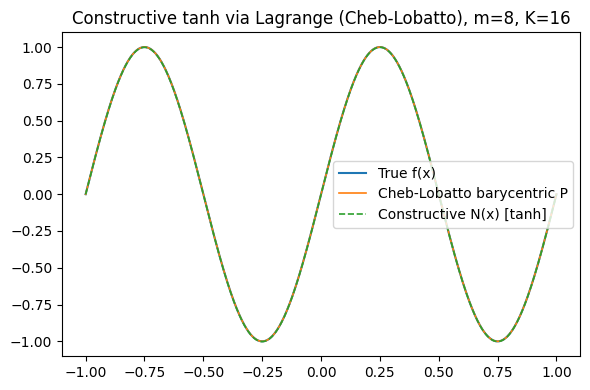

max_x |G_k - T_k| over k: [0.00000000e+00 8.43214387e-13 8.26250179e-12 1.48335477e-09
 6.22115670e-09 9.44834798e-07 1.62810427e-06 5.33713321e-04
 1.85760893e-04 3.61971892e-03 2.66555586e-02 1.69846864e-01
 1.24142183e+00 4.61240418e+00 6.12174218e+02 7.03808585e+01
 1.11022489e+04]
max over k: 11102.248923297506


In [7]:
# constructive_phi_barycentric.py
from __future__ import annotations
from typing import Optional, Literal
import numpy as np
import jax
import jax.numpy as jnp
from flax import nnx
import matplotlib.pyplot as plt

# ----- FP64
jax.config.update("jax_enable_x64", True)
DTYPE = jnp.float64


# =========================
# Chebyshev tools (Lobatto)
# =========================
def cheb_lobatto_nodes(K: int) -> jnp.ndarray:
    """Nodes x_j = cos(pi * j / K), j=0..K (Chebyshev–Lobatto)."""
    j = jnp.arange(K + 1, dtype=DTYPE)
    return jnp.cos(jnp.pi * j / K)


def cheb_vandermonde(x: jnp.ndarray, K: int) -> jnp.ndarray:
    """A[j,k] = T_k(x_j), k=0..K, via stable 3-term recurrence."""
    x = x.astype(DTYPE)
    n = x.shape[0]
    A = jnp.zeros((n, K + 1), dtype=DTYPE)
    if K >= 0: A = A.at[:, 0].set(1.0)
    if K >= 1: A = A.at[:, 1].set(x)
    if K >= 2:
        def body(carry, k):
            Tkm1, Tk = carry
            Tkp1 = 2.0 * x * Tk - Tkm1
            return (Tk, Tkp1), Tkp1
        (_, _), seq = jax.lax.scan(body, (A[:,0], A[:,1]), jnp.arange(1, K))
        A = A.at[:, 2:].set(seq.T)
    return A


def cheb_monomial_coeffs(K: int) -> jnp.ndarray:
    """C[k,p] s.t. T_k(x) = sum_{p=0}^k C[k,p] x^p."""
    C = np.zeros((K + 1, K + 1), dtype=np.float64)
    C[0,0] = 1.0
    if K >= 1: C[1,1] = 1.0
    for k in range(1, K):
        Tk, Tkm1 = C[k], C[k-1]
        two_x_Tk = np.zeros(K + 1, dtype=np.float64)
        two_x_Tk[1:] = 2.0 * Tk[:-1]
        C[k+1] = two_x_Tk - Tkm1
    return jnp.asarray(C, dtype=DTYPE)


# ==============================================
# Barycentric (2nd form) at Chebyshev–Lobatto
# ==============================================
def lobatto_bary_weights(K: int) -> jnp.ndarray:
    """Weights w_j = (-1)^j * c_j with c_0=c_K=1/2 else 1."""
    j = jnp.arange(K + 1, dtype=DTYPE)
    w = jnp.ones((K + 1,), dtype=DTYPE)
    w = w.at[0].set(0.5).at[-1].set(0.5)
    w = w * ((-1.0) ** j)
    return w


def barycentric_eval_lobatto(x_nodes: jnp.ndarray,
                             y_nodes: jnp.ndarray,
                             x_eval: jnp.ndarray) -> jnp.ndarray:
    """Second barycentric formula at Lobatto nodes."""
    K = x_nodes.shape[0] - 1
    w = lobatto_bary_weights(K)  # (K+1,)
    x_eval = jnp.asarray(x_eval, dtype=DTYPE)
    x_nodes = x_nodes.astype(DTYPE); y_nodes = y_nodes.astype(DTYPE)

    def one_point(x):
        diffs = x - x_nodes
        idx = jnp.argmin(jnp.abs(diffs))
        return jnp.where(jnp.isclose(diffs[idx], 0.0),
                         y_nodes[idx],
                         (jnp.sum(w * y_nodes / diffs) / jnp.sum(w / diffs)))
    return jax.vmap(one_point)(x_eval)


# ======================================
# Get Chebyshev T_k coefficients via SVD
# ======================================
def cheb_coeffs_from_lobatto(y_nodes: jnp.ndarray, K: int) -> jnp.ndarray:
    """
    For interpolation degree K at Lobatto nodes x_j = cos(pi j / K), j=0..K, solve:
       sum_{k=0}^K c_k T_k(x_j) = y_j
    using SVD (square but robust).
    """
    x_nodes = cheb_lobatto_nodes(K)
    A = cheb_vandermonde(x_nodes, K)     # (K+1, K+1)
    U, S, Vh = jnp.linalg.svd(A, full_matrices=False)
    print(f"SVD cond(A) ~ {float(S[0]/S[-1]):.3e}")
    Sinv = 1.0 / S
    c = (Vh.T * Sinv) @ (U.T @ y_nodes.astype(DTYPE))
    return c  # c_k (k=0..K)


# =======================================
# Activation + derivative helpers
# =======================================
def analytic_bias_for_tanh(choice="pi") -> tuple[float, float]:
    """Pick b with tanh(b)=t transcendental (helps avoid accidental cancellations)."""
    if choice == "pi":
        t = jnp.asarray(1.0 / jnp.pi, dtype=DTYPE)
    else:
        t = jnp.asarray(jnp.exp(-1.0), dtype=DTYPE)
    b = jnp.arctanh(t)
    return float(b), float(t)

def tanh_derivatives_at_b_poly(K: int, t: float) -> jnp.ndarray:
    """Return [tanh(b), tanh'(b), ..., tanh^{(K)}(b)], via P_{n+1}=(1-y^2)P'_n."""
    t = jnp.asarray(t, dtype=DTYPE)
    L = K + 2
    coeff = jnp.zeros(L, dtype=DTYPE).at[1].set(1.0)  # P0(y)=y
    derivs = jnp.zeros(K + 1, dtype=DTYPE).at[0].set(t)

    def poly_derivative(c):
        idx = jnp.arange(1, L, dtype=DTYPE)
        return jnp.zeros_like(c).at[:-1].set(idx * c[1:])

    def mul_by_1_minus_y2(c):
        return jnp.zeros_like(c).at[:].add(c).at[2:].add(-c[:-2])

    def poly_eval(c, t_):
        return jax.lax.fori_loop(0, L, lambda j, acc: acc * t_ + c[L-1-j], DTYPE(0.0))

    def step(n, carry):
        c, d = carry
        dc = poly_derivative(c)
        c_next = mul_by_1_minus_y2(dc)
        d = d.at[n+1].set(poly_eval(c_next, t))
        return (c_next, d)
    _, derivs = jax.lax.fori_loop(0, K, step, (coeff, derivs))
    return derivs

def phi_derivatives_at_b(K: int,
                         act: Literal["tanh","exp"],
                         b: float,
                         t_cached: Optional[float] = None) -> jnp.ndarray:
    """Return [φ^(p)(b)]_{p=0..K} for the chosen activation."""
    if act == "exp":
        return jnp.ones((K + 1,), dtype=DTYPE) * jnp.exp(DTYPE(b))
    elif act == "tanh":
        t = DTYPE(jnp.tanh(b)) if t_cached is None else DTYPE(t_cached)
        return tanh_derivatives_at_b_poly(K, t)
    else:
        raise ValueError("act must be 'tanh' or 'exp'.")


# =======================================
# Centered Fornberg finite-difference map
# =======================================
def fornberg_weights_centered(K: int) -> tuple[jnp.ndarray, jnp.ndarray]:
    """
    Uniform centered stencil on r = -K..K (unit step).
    Returns (r_grid, W) where W[p,i] are weights for the p-th derivative at 0
    with respect to the *unit* grid variable.
    """
    r = np.arange(-K, K + 1, dtype=np.float64)  # nodes r_i
    n = r.size
    m = K
    # Fornberg 1988 algorithm (coeffs for all orders up to m at once)
    c = np.zeros((m + 1, n), dtype=np.float64)
    c[0, 0] = 1.0
    c1 = 1.0
    c4 = r[0] - 0.0
    for i in range(1, n):
        mn = min(i, m)
        c2 = 1.0
        c5 = c4
        c4 = r[i] - 0.0
        for j in range(i):
            c3 = r[i] - r[j]
            c2 = c2 * c3
            for k in range(mn, 0, -1):
                c[k, i] = (c1 * (k * c[k - 1, i - 1] - c5 * c[k, i - 1])) / c2
            c[0, i] = (-c1 * c5 * c[0, i - 1]) / c2
            for k in range(mn, 0, -1):
                c[k, j] = ((c4 * c[k, j] - k * c[k - 1, j]) ) / c3
            c[0, j] = (c4 * c[0, j]) / c3
        c1 = c2
    return jnp.asarray(r, dtype=DTYPE), jnp.asarray(c, dtype=DTYPE)  # (K+1, 2K+1)


def binom_table(K: int) -> jnp.ndarray:
    B = np.zeros((K + 1, K + 1), dtype=np.float64)
    for p in range(K + 1):
        B[p, 0] = 1.0; B[p, p] = 1.0
        for r in range(1, p):
            B[p, r] = B[p - 1, r - 1] + B[p - 1, r]
    return jnp.asarray(B, dtype=DTYPE)


def sign_table(K: int) -> jnp.ndarray:
    ip = jnp.arange(K + 1, dtype=jnp.int32)[:, None]
    ir = jnp.arange(K + 1, dtype=jnp.int32)[None, :]
    S = jnp.where(((ip - ir) & 1) == 0, 1.0, -1.0)
    return jnp.tril(S).astype(DTYPE)


# ============================
# Constructive φ (NNX)
# ============================
class ConstructivePhi1D(nnx.Module):
    """
    One-hidden-layer constructive approximator with activation φ ∈ {tanh, exp}.
    Uses centered Fornberg stencil (r = -K..K), degree K (usually K=2m).
    """
    def __init__(self,
                 K: int,
                 V_cheb: jnp.ndarray,
                 act: Literal["tanh","exp"] = "tanh",
                 b: Optional[float] = None,
                 gamma: float = 0.5):
        self.K = int(K)
        self.act = act
        # heuristic: h ~ gamma / m with K=2m
        self.h = DTYPE(gamma / max(1, K // 2))

        # choose bias
        if act == "tanh":
            if b is None:
                b_val, t_val = analytic_bias_for_tanh("pi")
                self.b, self.t_cached = DTYPE(b_val), DTYPE(t_val)
            else:
                self.b = DTYPE(b); self.t_cached = jnp.tanh(self.b)
        elif act == "exp":
            self.b = DTYPE(0.0 if b is None else b)
            self.t_cached = None
        else:
            raise ValueError("act must be 'tanh' or 'exp'.")
        
        # tables
        self.C = cheb_monomial_coeffs(self.K)                 # (K+1,K+1)
        self.r_grid, W = fornberg_weights_centered(self.K)    # r in [-K..K], W[p,i]
        deriv = phi_derivatives_at_b(self.K, act=self.act, b=float(self.b), t_cached=self.t_cached)

        # build S_rowscaled[p,i] = W[p,i] / (h^p * φ^{(p)}(b))
        p = jnp.arange(self.K + 1, dtype=DTYPE)
        denom = (self.h ** p) * deriv                         # (K+1,)
        S_rowscaled = W / denom[:, None]                      # (K+1, 2K+1)

        # M[k,i] = sum_p C[k,p] * S_rowscaled[p,i]
        M = self.C @ S_rowscaled                              # (K+1, 2K+1)

        # row scaling for conditioning (preserves output)
        row_scale = jnp.maximum(jnp.max(jnp.abs(M), axis=1, keepdims=True), DTYPE(1.0))
        self.M = M / row_scale
        self.V = (V_cheb * row_scale.squeeze(-1)).astype(DTYPE)

        self.V_raw = V_cheb.astype(DTYPE)  # diagnostics

        # safety
        assert jnp.all(jnp.isfinite(self.M))
        assert jnp.all(jnp.isfinite(self.V))

    def _phi(self, z: jnp.ndarray) -> jnp.ndarray:
        return jnp.tanh(z) if self.act == "tanh" else jnp.exp(z)

    def __call__(self, x: jnp.ndarray) -> jnp.ndarray:
        x = jnp.asarray(x, dtype=DTYPE)
        print(f"x shape: {x.shape}, type: {type(x)}, dtype: {x.dtype}, x: {x}")
        print(f"self.b shape: {self.b.shape}, type: {type(self.b)}, dtype: {self.b.dtype}, self.b: {self.b}")
        Phi = self._phi(jnp.expand_dims(x, -1) * (self.r_grid * self.h) + self.b)  # (..., 2K+1)
        G = Phi @ self.M.T                                                         # (..., K+1)
        return G @ self.V


# ============================
# Build from barycentric data
# ============================
def build_model_from_barycentric(y_nodes: jnp.ndarray, K: int,
                                 act: Literal["tanh","exp"] = "tanh",
                                 b: float | None = None,
                                 gamma: float = 0.5) -> ConstructivePhi1D:
    """
    y_nodes are values at Lobatto nodes for degree K interpolation.
    Compute Chebyshev coefficients (no window — Theorem 2.3) and build the network.
    """
    V_cheb = cheb_coeffs_from_lobatto(y_nodes, K)
    return ConstructivePhi1D(K=K, V_cheb=V_cheb, act=act, b=b, gamma=gamma)



# ============================
# Demo / diagnostic
# ============================

k_freq = 1
m = 8
K = 2 * m               # degree K interpolation (Theorem 2.3)
act = "tanh"             # <-- switch between "tanh" and "exp"
gamma = 1.0             # try 0.25..0.8

x_nodes = cheb_lobatto_nodes(K)                     # (K+1,)
f = lambda x: jnp.sin(2.0 * jnp.pi * DTYPE(k_freq) * x)
y_nodes = f(x_nodes)

# Barycentric evaluation (for checking the interpolant)
xs = jnp.linspace(-1.0, 1.0, 1001, dtype=DTYPE)
y_bary = barycentric_eval_lobatto(x_nodes, y_nodes, xs)

# Build network from the same nodal data
model = build_model_from_barycentric(y_nodes, K=K, act=act, gamma=gamma)

# Evaluate network
y_pred = model(xs)
y_true = f(xs)

print(f"max |barycentric P - f|: {float(jnp.max(jnp.abs(y_bary - y_true))):.3e}, "
        f"rel L2 err: {float(jnp.linalg.norm(y_bary - y_true) / jnp.linalg.norm(y_true)):.3e}")
print(f"max |network N - f|   : {float(jnp.max(jnp.abs(y_pred - y_true))):.3e}, "
        f"rel L2 err: {float(jnp.linalg.norm(y_pred - y_true) / jnp.linalg.norm(y_true)):.3e}")
print(f"max |network - bary|  : {float(jnp.max(jnp.abs(y_pred - y_bary))):.3e}, "
        f"rel L2 err: {float(jnp.linalg.norm(y_pred - y_bary) / jnp.linalg.norm(y_bary)):.3e}")

# Chebyshev path consistency: G(x) ≈ T(x)
T = cheb_vandermonde(xs, K)             # (N,K+1)
y_poly = T @ model.V_raw                # direct Chebyshev polynomial
print("max |poly(T@V_raw) - bary|:", float(jnp.max(jnp.abs(y_poly - y_bary))))

# Plot
plt.figure(figsize=(6,4))
plt.plot(xs, y_true, label="True f(x)")
plt.plot(xs, y_bary, "-",  lw=1.2, label="Cheb-Lobatto barycentric P")
plt.plot(xs, y_pred, "--", lw=1.2, label=f"Constructive N(x) [{act}]")
plt.title(f"Constructive {act} via Lagrange (Cheb-Lobatto), m={m}, K={K}")
plt.legend(); plt.tight_layout(); plt.show()


# Micro-checks of the networkization alone (independent of V)
r_grid, W = fornberg_weights_centered(K)
p = jnp.arange(K + 1, dtype=DTYPE)
if act == "tanh":
    b0, t0 = analytic_bias_for_tanh("pi")
    deriv = tanh_derivatives_at_b_poly(K, t0)
    h = DTYPE(gamma / max(1, K // 2))
    Phi = jnp.tanh(xs[:, None] * (r_grid * h) + b0)
else:
    b0 = 0.0
    deriv = jnp.ones((K + 1,), dtype=DTYPE) * jnp.exp(DTYPE(b0))
    h = DTYPE(gamma / max(1, K // 2))
    Phi = jnp.exp(xs[:, None] * (r_grid * h) + b0)

denom = (h ** p) * deriv
S_rowscaled = W / denom[:, None]
C = cheb_monomial_coeffs(K)
G = Phi @ (C @ S_rowscaled).T
per_k = jnp.max(jnp.abs(G - cheb_vandermonde(xs, K)), axis=0)
print("max_x |G_k - T_k| over k:", np.array(per_k))
print("max over k:", float(per_k.max()))

max_x |G_k - T_k| over k: [0.00000000e+00 4.44089210e-15 1.65201186e-13 6.72478739e-12
 4.43954318e-10 1.66781035e-08 3.20490878e-07 2.34178291e-05
 1.85196653e-03 1.45662409e-01 8.09105727e+00 3.36690596e+02
 1.09246120e+04]
max over k: 10924.611989855766


In [14]:
r_grid

Array([-10.,  -9.,  -8.,  -7.,  -6.,  -5.,  -4.,  -3.,  -2.,  -1.,   0.,
         1.,   2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.,  10.],      dtype=float64)

SVD cond(A) ~ 1.414e+00
max |barycentric P - f|: 1.000e+00, rel L2 err: 1.000e+00
max |network N - f|   : 1.000e+00, rel L2 err: 1.000e+00
max |network - bary|  : 2.561e-15, rel L2 err: 2.659e+00
max |poly(T@V) - bary|: 3.0713127332347365e-15
max_x |G_k - T_k| over k: [0.         1.86466472 0.93233236]
max over k: 1.8646647167633874


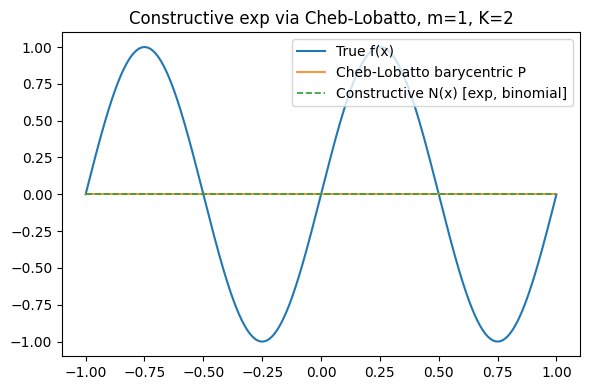

In [ ]:
# constructive_phi_barycentric_binomial.py
from __future__ import annotations
from typing import Optional, Literal
import numpy as np
import jax
import jax.numpy as jnp
from flax import nnx
import matplotlib.pyplot as plt

# ----- FP64
jax.config.update("jax_enable_x64", True)
DTYPE = jnp.float64


# =========================
# Chebyshev tools (Lobatto)
# =========================
def cheb_lobatto_nodes(K: int) -> jnp.ndarray:
    """Nodes x_j = cos(pi * j / K), j=0..K (Chebyshev–Lobatto)."""
    j = jnp.arange(K + 1, dtype=DTYPE)
    return jnp.cos(jnp.pi * j / K)


def cheb_vandermonde(x: jnp.ndarray, K: int) -> jnp.ndarray:
    """A[j,k] = T_k(x_j), k=0..K, via stable 3-term recurrence."""
    x = x.astype(DTYPE)
    n = x.shape[0]
    A = jnp.zeros((n, K + 1), dtype=DTYPE)
    if K >= 0: A = A.at[:, 0].set(1.0)
    if K >= 1: A = A.at[:, 1].set(x)
    if K >= 2:
        def body(carry, k):
            Tkm1, Tk = carry
            Tkp1 = 2.0 * x * Tk - Tkm1
            return (Tk, Tkp1), Tkp1
        (_, _), seq = jax.lax.scan(body, (A[:,0], A[:,1]), jnp.arange(1, K))
        A = A.at[:, 2:].set(seq.T)
    return A


def cheb_monomial_coeffs(K: int) -> jnp.ndarray:
    """C[k,p] s.t. T_k(x) = sum_{p=0}^k C[k,p] x^p."""
    C = np.zeros((K + 1, K + 1), dtype=np.float64)
    C[0,0] = 1.0
    if K >= 1: C[1,1] = 1.0
    for k in range(1, K):
        Tk, Tkm1 = C[k], C[k-1]
        two_x_Tk = np.zeros(K + 1, dtype=np.float64)
        two_x_Tk[1:] = 2.0 * Tk[:-1]
        C[k+1] = two_x_Tk - Tkm1
    return jnp.asarray(C, dtype=DTYPE)


# ==============================================
# Barycentric (2nd form) at Chebyshev–Lobatto
# ==============================================
def lobatto_bary_weights(K: int) -> jnp.ndarray:
    """Weights w_j = (-1)^j * c_j with c_0=c_K=1/2 else 1."""
    j = jnp.arange(K + 1, dtype=DTYPE)
    w = jnp.ones((K + 1,), dtype=DTYPE)
    w = w.at[0].set(0.5).at[-1].set(0.5)
    w = w * ((-1.0) ** j)
    return w


def barycentric_eval_lobatto(x_nodes: jnp.ndarray,
                             y_nodes: jnp.ndarray,
                             x_eval: jnp.ndarray) -> jnp.ndarray:
    """Second barycentric formula at Lobatto nodes."""
    K = x_nodes.shape[0] - 1
    w = lobatto_bary_weights(K)  # (K+1,)
    x_eval = jnp.asarray(x_eval, dtype=DTYPE)
    x_nodes = x_nodes.astype(DTYPE); y_nodes = y_nodes.astype(DTYPE)

    def one_point(x):
        diffs = x - x_nodes
        idx = jnp.argmin(jnp.abs(diffs))
        return jnp.where(jnp.isclose(diffs[idx], 0.0),
                         y_nodes[idx],
                         (jnp.sum(w * y_nodes / diffs) / jnp.sum(w / diffs)))
    return jax.vmap(one_point)(x_eval)


# ======================================
# Get Chebyshev T_k coefficients via SVD
# ======================================
def cheb_coeffs_from_lobatto(y_nodes: jnp.ndarray, K: int) -> jnp.ndarray:
    """
    For degree K at Lobatto nodes, solve sum_k c_k T_k(x_j) = y_j by SVD.
    """
    x_nodes = cheb_lobatto_nodes(K)
    A = cheb_vandermonde(x_nodes, K)     # (K+1, K+1)
    U, S, Vh = jnp.linalg.svd(A, full_matrices=False)
    print(f"SVD cond(A) ~ {float(S[0]/S[-1]):.3e}")
    Sinv = 1.0 / S
    c = (Vh.T * Sinv) @ (U.T @ y_nodes.astype(DTYPE))
    return c


# =======================================
# Activation + derivative helpers
# =======================================
def analytic_bias_for_tanh(choice="pi") -> tuple[float, float]:
    """Pick b with tanh(b)=t transcendental."""
    if choice == "pi":
        t = jnp.asarray(1.0 / jnp.pi, dtype=DTYPE)
    else:
        t = jnp.asarray(jnp.exp(-1.0), dtype=DTYPE)
    b = jnp.arctanh(t)
    return float(b), float(t)

def tanh_derivatives_at_b_poly(K: int, t: float) -> jnp.ndarray:
    """[tanh^(n)(b)] via derivative-polynomial recurrence."""
    t = jnp.asarray(t, dtype=DTYPE)
    L = K + 2
    coeff = jnp.zeros(L, dtype=DTYPE).at[1].set(1.0)
    derivs = jnp.zeros(K + 1, dtype=DTYPE).at[0].set(t)
    def poly_derivative(c):
        idx = jnp.arange(1, L, dtype=DTYPE)
        return jnp.zeros_like(c).at[:-1].set(idx * c[1:])
    def mul_by_1_minus_y2(c):
        return jnp.zeros_like(c).at[:].add(c).at[2:].add(-c[:-2])
    def poly_eval(c, t_):
        return jax.lax.fori_loop(0, L, lambda j, acc: acc*t_ + c[L-1-j], DTYPE(0.0))
    def step(n, carry):
        c, d = carry
        dc = poly_derivative(c)
        c_next = mul_by_1_minus_y2(dc)
        d = d.at[n+1].set(poly_eval(c_next, t))
        return (c_next, d)
    _, derivs = jax.lax.fori_loop(0, K, step, (coeff, derivs))
    return derivs

def phi_derivatives_at_b(K: int,
                         act: Literal["tanh","exp"],
                         b: float,
                         t_cached: Optional[float] = None) -> jnp.ndarray:
    """Return [φ^(p)(b)] for the chosen activation."""
    if act == "exp":
        return jnp.ones((K + 1,), dtype=DTYPE) * jnp.exp(DTYPE(b))
    elif act == "tanh":
        t = DTYPE(jnp.tanh(b)) if t_cached is None else DTYPE(t_cached)
        return tanh_derivatives_at_b_poly(K, t)
    else:
        raise ValueError("act must be 'tanh' or 'exp'.")


# =======================================
# Mhaskar binomial finite-difference map (eq. 3.19)
# =======================================
def mhaskar_binomial_S(K: int) -> jnp.ndarray:
    """
    Build S_bin[p, j] for p=0..K and j indexing r' in {-K, ..., K} (step 1).
    For a given p, only columns with |r'|<=p and same parity as p are nonzero:
      r' = 2r - p  with r=0..p
      coeff = (-1)^r * binom(p, r)
    """
    S = np.zeros((K + 1, 2 * K + 1), dtype=np.float64)
    for p in range(K + 1):
        for r in range(p + 1):
            rprime = 2 * r - p
            col = rprime + K
            S[p, col] += ((-1.0) ** r) * comb_int(p, r)
    return jnp.asarray(S, dtype=DTYPE)

def comb_int(n: int, k: int) -> float:
    """Exact integer binomial then cast to float (stable for moderate n)."""
    if k < 0 or k > n: return 0.0
    k = min(k, n - k)
    c = 1
    for i in range(1, k + 1):
        c = (c * (n - k + i)) // i
    return float(c)


# =======================================
# Centered Fornberg finite-difference map (optional)
# =======================================
def fornberg_weights_centered(K: int) -> tuple[jnp.ndarray, jnp.ndarray]:
    r = np.arange(-K, K + 1, dtype=np.float64)
    n = r.size
    m = K
    c = np.zeros((m + 1, n), dtype=np.float64)
    c[0, 0] = 1.0
    c1 = 1.0
    c4 = r[0]
    for i in range(1, n):
        mn = min(i, m)
        c2 = 1.0
        c5 = c4
        c4 = r[i]
        for j in range(i):
            c3 = r[i] - r[j]
            c2 *= c3
            for k in range(mn, 0, -1):
                c[k, j] = ((c4 * c[k, j] - k * c[k - 1, j]) ) / c3
            c[0, j] = (c4 * c[0, j]) / c3
        for k in range(mn, 0, -1):
            c[k, i] = (c1 * (k * c[k - 1, i - 1] - c5 * c[k, i - 1])) / c2
        c[0, i] = (-c1 * c5 * c[0, i - 1]) / c2
        c1 = c2
    return jnp.asarray(r, dtype=DTYPE), jnp.asarray(c, dtype=DTYPE)


# ============================
# Constructive φ (NNX)
# ============================
class ConstructivePhi1D(nnx.Module):
    """
    One-hidden-layer constructive approximator with φ ∈ {tanh, exp}.
    You can choose `scheme="binomial"` (Mhaskar 3.19) or `scheme="fornberg"`.
    """
    def __init__(self,
                 K: int,
                 V_cheb: jnp.ndarray,
                 act: Literal["tanh","exp"] = "tanh",
                 scheme: Literal["binomial","fornberg"] = "binomial",
                 b: Optional[float] = None,
                 gamma: float = 0.5,
                 col_balance_exp: bool = True):
        self.K = int(K)
        self.act = act
        self.scheme = scheme
        # heuristic: h ~ gamma / m with K=2m
        self.h = DTYPE(gamma / max(1, K // 2))

        # choose bias
        if act == "tanh":
            if b is None:
                b_val, t_val = analytic_bias_for_tanh("pi")
                self.b, self.t_cached = DTYPE(b_val), DTYPE(t_val)
            else:
                self.b = DTYPE(b); self.t_cached = jnp.tanh(self.b)
        elif act == "exp":
            self.b = DTYPE(0.0 if b is None else b)
            self.t_cached = None
        else:
            raise ValueError("act must be 'tanh' or 'exp'.")

        if V_cheb.shape != (self.K + 1,):
            raise ValueError(f"V must have shape ({self.K+1},), got {V_cheb.shape}")
        self.V = V_cheb.astype(DTYPE)

        # derivative vector
        deriv = phi_derivatives_at_b(self.K, act=self.act, b=float(self.b), t_cached=self.t_cached)

        # dictionary columns indexed by r' in {-K,..,K}
        self.r_grid = jnp.arange(-self.K, self.K + 1, dtype=DTYPE)  # length 2K+1

        # build S_rowscaled[p, j]
        if scheme == "binomial":
            S_base = mhaskar_binomial_S(self.K)                           # (K+1, 2K+1)
        elif scheme == "fornberg":
            r_tmp, W = fornberg_weights_centered(self.K)                  # r_tmp = [-K..K]
            assert jnp.all(r_tmp == self.r_grid)
            S_base = W
        else:
            raise ValueError("scheme must be 'binomial' or 'fornberg'.")

        p = jnp.arange(self.K + 1, dtype=DTYPE)
        denom = (self.h ** p) * deriv                                     # (K+1,)
        S_rowscaled = S_base / denom[:, None]                              # (K+1, 2K+1)

        # Chebyshev-to-monomial map
        C = cheb_monomial_coeffs(self.K)                                   # (K+1, K+1)

        # Optional column balancing for exp to tame dynamic range of Φ
        if col_balance_exp and self.act == "exp":
            # Worst-case |x| ≤ 1 ⇒ max Φ_col ~ exp(b + |r'| h)
            # balance so typical magnitudes stay near 1
            col_scale = jnp.exp(-jnp.abs(self.r_grid) * self.h)            # (2K+1,)
        else:
            col_scale = jnp.ones((2 * self.K + 1,), dtype=DTYPE)

        # Composite map such that (Φ*col_scale) @ (M_scaled.T) == G
        M = C @ (S_rowscaled / col_scale[None, :])                         # (K+1, 2K+1)
        row_scale = jnp.maximum(jnp.max(jnp.abs(M), axis=1, keepdims=True), DTYPE(1.0))
        self.M = M / row_scale
        self.V = self.V * row_scale.squeeze(-1)
        self.col_scale = col_scale

        # safety
        assert jnp.all(jnp.isfinite(self.M))
        assert jnp.all(jnp.isfinite(self.V))

    def _phi(self, z: jnp.ndarray) -> jnp.ndarray:
        return jnp.tanh(z) if self.act == "tanh" else jnp.exp(z)

    def __call__(self, x: jnp.ndarray) -> jnp.ndarray:
        x = jnp.asarray(x, dtype=DTYPE)
        # Φ columns: φ((r' h) x + b)
        Phi = self._phi(jnp.expand_dims(x, -1) * (self.r_grid * self.h) + self.b)  # (..., 2K+1)
        Phi_bal = Phi * self.col_scale                                            # column balancing
        G = Phi_bal @ self.M.T                                                    # (..., K+1)
        return G @ self.V


# ============================
# Build from barycentric data
# ============================
def build_model_from_barycentric(y_nodes: jnp.ndarray, K: int,
                                 act: Literal["tanh","exp"] = "tanh",
                                 scheme: Literal["binomial","fornberg"] = "binomial",
                                 b: float | None = None,
                                 gamma: float = 0.5) -> ConstructivePhi1D:
    """
    y_nodes are values at Lobatto nodes for degree K interpolation.
    Compute Chebyshev coefficients (no window — Theorem 2.3) and build the network.
    """
    V_cheb = cheb_coeffs_from_lobatto(y_nodes, K)
    return ConstructivePhi1D(K=K, V_cheb=V_cheb, act=act, scheme=scheme, b=b, gamma=gamma)



# ============================
# Demo / diagnostic
# ============================
if __name__ == "__main__":
    k_freq = 1
    m = 4
    K = 2 * m
    act = "exp"            # or "tanh"
    scheme = "binomial"    # <-- key change vs Fornberg
    gamma = 1.0            # try 0.5..1.0; avoid h^K too tiny

    x_nodes = cheb_lobatto_nodes(K)
    f = lambda x: jnp.sin(2.0 * jnp.pi * DTYPE(k_freq) * x)
    y_nodes = f(x_nodes)

    xs = jnp.linspace(-1.0, 1.0, 1001, dtype=DTYPE)
    y_bary = barycentric_eval_lobatto(x_nodes, y_nodes, xs)

    model = build_model_from_barycentric(y_nodes, K=K, act=act, scheme=scheme, gamma=gamma)

    y_pred = model(xs)
    y_true = f(xs)

    print(f"max |barycentric P - f|: {float(jnp.max(jnp.abs(y_bary - y_true))):.3e}, "
          f"rel L2 err: {float(jnp.linalg.norm(y_bary - y_true) / jnp.linalg.norm(y_true)):.3e}")
    print(f"max |network N - f|   : {float(jnp.max(jnp.abs(y_pred - y_true))):.3e}, "
          f"rel L2 err: {float(jnp.linalg.norm(y_pred - y_true) / jnp.linalg.norm(y_true)):.3e}")
    print(f"max |network - bary|  : {float(jnp.max(jnp.abs(y_pred - y_bary))):.3e}, "
          f"rel L2 err: {float(jnp.linalg.norm(y_pred - y_bary) / jnp.linalg.norm(y_bary)):.3e}")

    # Chebyshev path consistency
    T = cheb_vandermonde(xs, K)
    y_poly = T @ model.V
    print("max |poly(T@V) - bary|:", float(jnp.max(jnp.abs(y_poly - y_bary))))

    # Micro-check: how well do we reproduce T_k?
    # Build G_k via the fixed map and compare against exact T_k.
    # (This checks the numeric quality of S and the C@S composition.)
    r_grid = jnp.arange(-K, K + 1, dtype=DTYPE)
    Phi = (jnp.exp if act=="exp" else jnp.tanh)(xs[:, None] * (r_grid * model.h) + model.b) * model.col_scale
    G = Phi @ model.M.T
    T_exact = cheb_vandermonde(xs, K)
    per_k = jnp.max(jnp.abs(G - T_exact), axis=0)
    print("max_x |G_k - T_k| over k:", np.array(per_k))
    print("max over k:", float(per_k.max()))

    # Plot
    plt.figure(figsize=(6,4))
    plt.plot(xs, y_true, label="True f(x)")
    plt.plot(xs, y_bary, "-",  lw=1.2, label="Cheb-Lobatto barycentric P")
    plt.plot(xs, y_pred, "--", lw=1.2, label=f"Constructive N(x) [{act}, {scheme}]")
    plt.title(f"Constructive {act} via Cheb-Lobatto, m={m}, K={K}")
    plt.legend(); plt.tight_layout(); plt.show()


SVD cond(A) ~ 1.602e+00
max |barycentric P - f|: 1.869e-06, rel L2 err: 1.498e-06
max |network N - f|   : 1.584e+03, rel L2 err: 3.628e+02
max |network - bary|  : 1.584e+03, rel L2 err: 3.628e+02
max |poly(T@V) - bary|: 9.790298744453523e+16
max_x |G_k - T_k| over k: [0.         1.22119922 0.99610895 1.00375365 1.00007449 1.00006149
 1.00000286 1.00000096 1.         1.00000001 1.         1.
 1.         1.         1.         1.         1.        ]
max over k: 1.221199216928595


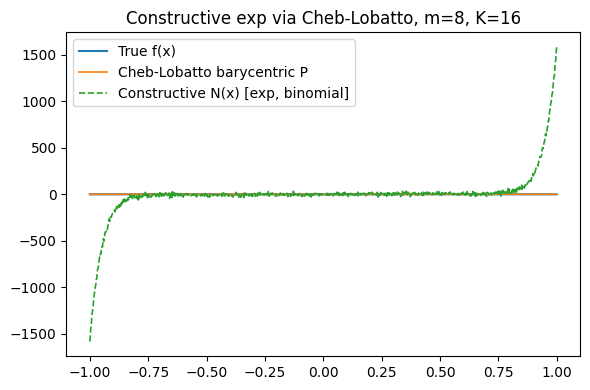

In [10]:
# constructive_phi_barycentric_binomial.py
from __future__ import annotations
from typing import Optional, Literal
import numpy as np
import jax
import jax.numpy as jnp
from flax import nnx
import matplotlib.pyplot as plt

# ----- FP64
jax.config.update("jax_enable_x64", True)
DTYPE = jnp.float64


# =========================
# Chebyshev tools (Lobatto)
# =========================
def cheb_lobatto_nodes(K: int) -> jnp.ndarray:
    """Nodes x_j = cos(pi * j / K), j=0..K (Chebyshev–Lobatto)."""
    j = jnp.arange(K + 1, dtype=DTYPE)
    return jnp.cos(jnp.pi * j / K)


def cheb_vandermonde(x: jnp.ndarray, K: int) -> jnp.ndarray:
    """A[j,k] = T_k(x_j), k=0..K, via stable 3-term recurrence."""
    x = x.astype(DTYPE)
    n = x.shape[0]
    A = jnp.zeros((n, K + 1), dtype=DTYPE)
    if K >= 0: A = A.at[:, 0].set(1.0)
    if K >= 1: A = A.at[:, 1].set(x)
    if K >= 2:
        def body(carry, k):
            Tkm1, Tk = carry
            Tkp1 = 2.0 * x * Tk - Tkm1
            return (Tk, Tkp1), Tkp1
        (_, _), seq = jax.lax.scan(body, (A[:,0], A[:,1]), jnp.arange(1, K))
        A = A.at[:, 2:].set(seq.T)
    return A


def cheb_monomial_coeffs(K: int) -> jnp.ndarray:
    """C[k,p] s.t. T_k(x) = sum_{p=0}^k C[k,p] x^p."""
    C = np.zeros((K + 1, K + 1), dtype=np.float64)
    C[0,0] = 1.0
    if K >= 1: C[1,1] = 1.0
    for k in range(1, K):
        Tk, Tkm1 = C[k], C[k-1]
        two_x_Tk = np.zeros(K + 1, dtype=np.float64)
        two_x_Tk[1:] = 2.0 * Tk[:-1]
        C[k+1] = two_x_Tk - Tkm1
    return jnp.asarray(C, dtype=DTYPE)


# ==============================================
# Barycentric (2nd form) at Chebyshev–Lobatto
# ==============================================
def lobatto_bary_weights(K: int) -> jnp.ndarray:
    """Weights w_j = (-1)^j * c_j with c_0=c_K=1/2 else 1."""
    j = jnp.arange(K + 1, dtype=DTYPE)
    w = jnp.ones((K + 1,), dtype=DTYPE)
    w = w.at[0].set(0.5).at[-1].set(0.5)
    w = w * ((-1.0) ** j)
    return w


def barycentric_eval_lobatto(x_nodes: jnp.ndarray,
                             y_nodes: jnp.ndarray,
                             x_eval: jnp.ndarray) -> jnp.ndarray:
    """Second barycentric formula at Lobatto nodes."""
    K = x_nodes.shape[0] - 1
    w = lobatto_bary_weights(K)  # (K+1,)
    x_eval = jnp.asarray(x_eval, dtype=DTYPE)
    x_nodes = x_nodes.astype(DTYPE); y_nodes = y_nodes.astype(DTYPE)

    def one_point(x):
        diffs = x - x_nodes
        idx = jnp.argmin(jnp.abs(diffs))
        return jnp.where(jnp.isclose(diffs[idx], 0.0),
                         y_nodes[idx],
                         (jnp.sum(w * y_nodes / diffs) / jnp.sum(w / diffs)))
    return jax.vmap(one_point)(x_eval)


# ======================================
# Get Chebyshev T_k coefficients via SVD
# ======================================
def cheb_coeffs_from_lobatto(y_nodes: jnp.ndarray, K: int) -> jnp.ndarray:
    """
    For degree K at Lobatto nodes, solve sum_k c_k T_k(x_j) = y_j by SVD.
    """
    x_nodes = cheb_lobatto_nodes(K)
    A = cheb_vandermonde(x_nodes, K)     # (K+1, K+1)
    U, S, Vh = jnp.linalg.svd(A, full_matrices=False)
    print(f"SVD cond(A) ~ {float(S[0]/S[-1]):.3e}")
    Sinv = 1.0 / S
    c = (Vh.T * Sinv) @ (U.T @ y_nodes.astype(DTYPE))
    return c


# =======================================
# Activation + derivative helpers
# =======================================
def analytic_bias_for_tanh(choice="pi") -> tuple[float, float]:
    """Pick b with tanh(b)=t transcendental."""
    if choice == "pi":
        t = jnp.asarray(1.0 / jnp.pi, dtype=DTYPE)
    else:
        t = jnp.asarray(jnp.exp(-1.0), dtype=DTYPE)
    b = jnp.arctanh(t)
    return float(b), float(t)

def tanh_derivatives_at_b_poly(K: int, t: float) -> jnp.ndarray:
    """[tanh^(n)(b)] via derivative-polynomial recurrence."""
    t = jnp.asarray(t, dtype=DTYPE)
    L = K + 2
    coeff = jnp.zeros(L, dtype=DTYPE).at[1].set(1.0)
    derivs = jnp.zeros(K + 1, dtype=DTYPE).at[0].set(t)
    def poly_derivative(c):
        idx = jnp.arange(1, L, dtype=DTYPE)
        return jnp.zeros_like(c).at[:-1].set(idx * c[1:])
    def mul_by_1_minus_y2(c):
        return jnp.zeros_like(c).at[:].add(c).at[2:].add(-c[:-2])
    def poly_eval(c, t_):
        return jax.lax.fori_loop(0, L, lambda j, acc: acc*t_ + c[L-1-j], DTYPE(0.0))
    def step(n, carry):
        c, d = carry
        dc = poly_derivative(c)
        c_next = mul_by_1_minus_y2(dc)
        d = d.at[n+1].set(poly_eval(c_next, t))
        return (c_next, d)
    _, derivs = jax.lax.fori_loop(0, K, step, (coeff, derivs))
    return derivs

def phi_derivatives_at_b(K: int,
                         act: Literal["tanh","exp"],
                         b: float,
                         t_cached: Optional[float] = None) -> jnp.ndarray:
    """Return [φ^(p)(b)] for the chosen activation."""
    if act == "exp":
        return jnp.ones((K + 1,), dtype=DTYPE) * jnp.exp(DTYPE(b))
    elif act == "tanh":
        t = DTYPE(jnp.tanh(b)) if t_cached is None else DTYPE(t_cached)
        return tanh_derivatives_at_b_poly(K, t)
    else:
        raise ValueError("act must be 'tanh' or 'exp'.")


# =======================================
# Mhaskar binomial finite-difference map (eq. 3.19)
# =======================================
def mhaskar_binomial_S(K: int) -> jnp.ndarray:
    """
    Build S_bin[p, j] for p=0..K and j indexing r' in {-K, ..., K} (step 1).
    For a given p, only columns with |r'|<=p and same parity as p are nonzero:
      r' = 2r - p  with r=0..p
      coeff = (-1)^r * binom(p, r)
    """
    S = np.zeros((K + 1, 2 * K + 1), dtype=np.float64)
    for p in range(K + 1):
        for r in range(p + 1):
            rprime = 2 * r - p
            col = rprime + K
            S[p, col] += ((-1.0) ** r) * comb_int(p, r)
    return jnp.asarray(S, dtype=DTYPE)

def comb_int(n: int, k: int) -> float:
    """Exact integer binomial then cast to float (stable for moderate n)."""
    if k < 0 or k > n: return 0.0
    k = min(k, n - k)
    c = 1
    for i in range(1, k + 1):
        c = (c * (n - k + i)) // i
    return float(c)


# =======================================
# Centered Fornberg finite-difference map (optional)
# =======================================
def fornberg_weights_centered(K: int) -> tuple[jnp.ndarray, jnp.ndarray]:
    r = np.arange(-K, K + 1, dtype=np.float64)
    n = r.size
    m = K
    c = np.zeros((m + 1, n), dtype=np.float64)
    c[0, 0] = 1.0
    c1 = 1.0
    c4 = r[0]
    for i in range(1, n):
        mn = min(i, m)
        c2 = 1.0
        c5 = c4
        c4 = r[i]
        for j in range(i):
            c3 = r[i] - r[j]
            c2 *= c3
            for k in range(mn, 0, -1):
                c[k, j] = ((c4 * c[k, j] - k * c[k - 1, j]) ) / c3
            c[0, j] = (c4 * c[0, j]) / c3
        for k in range(mn, 0, -1):
            c[k, i] = (c1 * (k * c[k - 1, i - 1] - c5 * c[k, i - 1])) / c2
        c[0, i] = (-c1 * c5 * c[0, i - 1]) / c2
        c1 = c2
    return jnp.asarray(r, dtype=DTYPE), jnp.asarray(c, dtype=DTYPE)


# ============================
# Constructive φ (NNX)
# ============================
class ConstructivePhi1D(nnx.Module):
    """
    One-hidden-layer constructive approximator with φ ∈ {tanh, exp}.
    You can choose `scheme="binomial"` (Mhaskar 3.19) or `scheme="fornberg"`.
    """
    def __init__(self,
                 K: int,
                 V_cheb: jnp.ndarray,
                 act: Literal["tanh","exp"] = "tanh",
                 scheme: Literal["binomial","fornberg"] = "binomial",
                 b: Optional[float] = None,
                 gamma: float = 0.5,
                 col_balance_exp: bool = True):
        self.K = int(K)
        self.act = act
        self.scheme = scheme
        # heuristic: h ~ gamma / m with K=2m
        self.h = DTYPE(gamma / max(1, K // 2))

        # choose bias
        if act == "tanh":
            if b is None:
                b_val, t_val = analytic_bias_for_tanh("pi")
                self.b, self.t_cached = DTYPE(b_val), DTYPE(t_val)
            else:
                self.b = DTYPE(b); self.t_cached = jnp.tanh(self.b)
        elif act == "exp":
            self.b = DTYPE(0.0 if b is None else b)
            self.t_cached = None
        else:
            raise ValueError("act must be 'tanh' or 'exp'.")

        if V_cheb.shape != (self.K + 1,):
            raise ValueError(f"V must have shape ({self.K+1},), got {V_cheb.shape}")
        self.V = V_cheb.astype(DTYPE)

        # derivative vector
        deriv = phi_derivatives_at_b(self.K, act=self.act, b=float(self.b), t_cached=self.t_cached)

        # dictionary columns indexed by r' in {-K,..,K}
        self.r_grid = jnp.arange(-self.K, self.K + 1, dtype=DTYPE)  # length 2K+1

        # build S_rowscaled[p, j]
        if scheme == "binomial":
            S_base = mhaskar_binomial_S(self.K)                           # (K+1, 2K+1)
        elif scheme == "fornberg":
            r_tmp, W = fornberg_weights_centered(self.K)                  # r_tmp = [-K..K]
            assert jnp.all(r_tmp == self.r_grid)
            S_base = W
        else:
            raise ValueError("scheme must be 'binomial' or 'fornberg'.")

        p = jnp.arange(self.K + 1, dtype=DTYPE)
        denom = (self.h ** p) * deriv                                     # (K+1,)
        S_rowscaled = S_base / denom[:, None]                              # (K+1, 2K+1)

        # Chebyshev-to-monomial map
        C = cheb_monomial_coeffs(self.K)                                   # (K+1, K+1)

        # Optional column balancing for exp to tame dynamic range of Φ
        if col_balance_exp and self.act == "exp":
            # Worst-case |x| ≤ 1 ⇒ max Φ_col ~ exp(b + |r'| h)
            # balance so typical magnitudes stay near 1
            col_scale = jnp.exp(-jnp.abs(self.r_grid) * self.h)            # (2K+1,)
        else:
            col_scale = jnp.ones((2 * self.K + 1,), dtype=DTYPE)

        # Composite map such that (Φ*col_scale) @ (M_scaled.T) == G
        M = C @ (S_rowscaled / col_scale[None, :])                         # (K+1, 2K+1)
        row_scale = jnp.maximum(jnp.max(jnp.abs(M), axis=1, keepdims=True), DTYPE(1.0))
        self.M = M / row_scale
        self.V = self.V * row_scale.squeeze(-1)
        self.col_scale = col_scale

        # safety
        assert jnp.all(jnp.isfinite(self.M))
        assert jnp.all(jnp.isfinite(self.V))

    def _phi(self, z: jnp.ndarray) -> jnp.ndarray:
        return jnp.tanh(z) if self.act == "tanh" else jnp.exp(z)

    def __call__(self, x: jnp.ndarray) -> jnp.ndarray:
        x = jnp.asarray(x, dtype=DTYPE)
        # Φ columns: φ((r' h) x + b)
        Phi = self._phi(jnp.expand_dims(x, -1) * (self.r_grid * self.h) + self.b)  # (..., 2K+1)
        Phi_bal = Phi * self.col_scale                                            # column balancing
        G = Phi_bal @ self.M.T                                                    # (..., K+1)
        return G @ self.V


# ============================
# Build from barycentric data
# ============================
def build_model_from_barycentric(y_nodes: jnp.ndarray, K: int,
                                 act: Literal["tanh","exp"] = "tanh",
                                 scheme: Literal["binomial","fornberg"] = "binomial",
                                 b: float | None = None,
                                 gamma: float = 0.5) -> ConstructivePhi1D:
    """
    y_nodes are values at Lobatto nodes for degree K interpolation.
    Compute Chebyshev coefficients (no window — Theorem 2.3) and build the network.
    """
    V_cheb = cheb_coeffs_from_lobatto(y_nodes, K)
    return ConstructivePhi1D(K=K, V_cheb=V_cheb, act=act, scheme=scheme, b=b, gamma=gamma)



# ============================
# Demo / diagnostic
# ============================
if __name__ == "__main__":
    k_freq = 1
    m = 8
    K = 2 * m
    act = "exp"            # or "tanh"
    scheme = "binomial"    # <-- key change vs Fornberg
    gamma = 1.0            # try 0.5..1.0; avoid h^K too tiny

    x_nodes = cheb_lobatto_nodes(K)
    f = lambda x: jnp.sin(2.0 * jnp.pi * DTYPE(k_freq) * x)
    y_nodes = f(x_nodes)

    xs = jnp.linspace(-1.0, 1.0, 1001, dtype=DTYPE)
    y_bary = barycentric_eval_lobatto(x_nodes, y_nodes, xs)

    model = build_model_from_barycentric(y_nodes, K=K, act=act, scheme=scheme, gamma=gamma)

    y_pred = model(xs)
    y_true = f(xs)

    print(f"max |barycentric P - f|: {float(jnp.max(jnp.abs(y_bary - y_true))):.3e}, "
          f"rel L2 err: {float(jnp.linalg.norm(y_bary - y_true) / jnp.linalg.norm(y_true)):.3e}")
    print(f"max |network N - f|   : {float(jnp.max(jnp.abs(y_pred - y_true))):.3e}, "
          f"rel L2 err: {float(jnp.linalg.norm(y_pred - y_true) / jnp.linalg.norm(y_true)):.3e}")
    print(f"max |network - bary|  : {float(jnp.max(jnp.abs(y_pred - y_bary))):.3e}, "
          f"rel L2 err: {float(jnp.linalg.norm(y_pred - y_bary) / jnp.linalg.norm(y_bary)):.3e}")

    # Chebyshev path consistency
    T = cheb_vandermonde(xs, K)
    y_poly = T @ model.V
    print("max |poly(T@V) - bary|:", float(jnp.max(jnp.abs(y_poly - y_bary))))

    # Micro-check: how well do we reproduce T_k?
    # Build G_k via the fixed map and compare against exact T_k.
    # (This checks the numeric quality of S and the C@S composition.)
    r_grid = jnp.arange(-K, K + 1, dtype=DTYPE)
    Phi = (jnp.exp if act=="exp" else jnp.tanh)(xs[:, None] * (r_grid * model.h) + model.b) * model.col_scale
    G = Phi @ model.M.T
    T_exact = cheb_vandermonde(xs, K)
    per_k = jnp.max(jnp.abs(G - T_exact), axis=0)
    print("max_x |G_k - T_k| over k:", np.array(per_k))
    print("max over k:", float(per_k.max()))

    # Plot
    plt.figure(figsize=(6,4))
    plt.plot(xs, y_true, label="True f(x)")
    plt.plot(xs, y_bary, "-",  lw=1.2, label="Cheb-Lobatto barycentric P")
    plt.plot(xs, y_pred, "--", lw=1.2, label=f"Constructive N(x) [{act}, {scheme}]")
    plt.title(f"Constructive {act} via Cheb-Lobatto, m={m}, K={K}")
    plt.legend(); plt.tight_layout(); plt.show()


SVD cond(A) ~ 1.602e+00
max |barycentric P - f|: 1.869e-06, rel L2 err: 1.498e-06
max |network N - f|   : 3.880e-02, rel L2 err: 1.636e-02
max |network - bary|  : 3.880e-02, rel L2 err: 1.636e-02
max |poly(T @ V_raw) - bary|: 2.6645352591003757e-15
max_x |G_k - T_k| over k: [0.         0.81873075 0.99009901 0.99940275 0.99996711 0.99999821
 0.9999999  0.99999999 1.         1.         1.         1.
 1.         1.         1.         1.         1.        ]
max over k: 1.0000000000000004


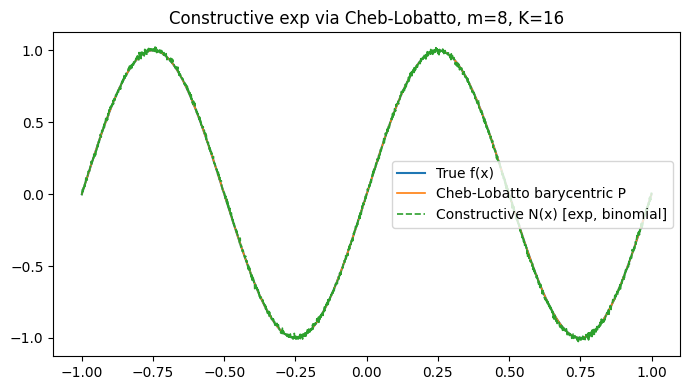

In [5]:
# constructive_phi_barycentric_binomial_fixed.py
from __future__ import annotations
from typing import Optional, Literal
import numpy as np
import jax
import jax.numpy as jnp
from flax import nnx
import matplotlib.pyplot as plt

# ----- FP64
jax.config.update("jax_enable_x64", True)
DTYPE = jnp.float64

# -------------------------------
# Chebyshev–Lobatto + utilities
# -------------------------------
def cheb_lobatto_nodes(K: int) -> jnp.ndarray:
    j = jnp.arange(K + 1, dtype=DTYPE)
    return jnp.cos(jnp.pi * j / K)

def cheb_vandermonde(x: jnp.ndarray, K: int) -> jnp.ndarray:
    x = x.astype(DTYPE)
    n = x.shape[0]
    A = jnp.zeros((n, K + 1), dtype=DTYPE)
    if K >= 0: A = A.at[:, 0].set(1.0)
    if K >= 1: A = A.at[:, 1].set(x)
    if K >= 2:
        def body(carry, k):
            Tkm1, Tk = carry
            Tkp1 = 2.0 * x * Tk - Tkm1
            return (Tk, Tkp1), Tkp1
        (_, _), seq = jax.lax.scan(body, (A[:,0], A[:,1]), jnp.arange(1, K))
        A = A.at[:, 2:].set(seq.T)
    return A

def cheb_monomial_coeffs(K: int) -> jnp.ndarray:
    C = np.zeros((K + 1, K + 1), dtype=np.float64)
    C[0,0] = 1.0
    if K >= 1: C[1,1] = 1.0
    for k in range(1, K):
        Tk, Tkm1 = C[k], C[k-1]
        two_x_Tk = np.zeros(K + 1, dtype=np.float64)
        two_x_Tk[1:] = 2.0 * Tk[:-1]
        C[k+1] = two_x_Tk - Tkm1
    return jnp.asarray(C, dtype=DTYPE)

# -------------------------------
# Barycentric (second form)
# -------------------------------
def lobatto_bary_weights(K: int) -> jnp.ndarray:
    j = jnp.arange(K + 1, dtype=DTYPE)
    w = jnp.ones((K + 1,), dtype=DTYPE)
    w = w.at[0].set(0.5).at[-1].set(0.5)
    return w * ((-1.0) ** j)

def barycentric_eval_lobatto(x_nodes: jnp.ndarray, y_nodes: jnp.ndarray, x_eval: jnp.ndarray) -> jnp.ndarray:
    K = x_nodes.shape[0] - 1
    w = lobatto_bary_weights(K)
    x_eval = jnp.asarray(x_eval, dtype=DTYPE)
    x_nodes = x_nodes.astype(DTYPE); y_nodes = y_nodes.astype(DTYPE)
    def one_point(x):
        diffs = x - x_nodes
        idx = jnp.argmin(jnp.abs(diffs))
        return jnp.where(jnp.isclose(diffs[idx], 0.0),
                         y_nodes[idx],
                         (jnp.sum(w * y_nodes / diffs) / jnp.sum(w / diffs)))
    return jax.vmap(one_point)(x_eval)

def cheb_coeffs_from_lobatto(y_nodes: jnp.ndarray, K: int) -> jnp.ndarray:
    x_nodes = cheb_lobatto_nodes(K)
    A = cheb_vandermonde(x_nodes, K)     # (K+1, K+1)
    U, S, Vh = jnp.linalg.svd(A, full_matrices=False)
    print(f"SVD cond(A) ~ {float(S[0]/S[-1]):.3e}")
    Sinv = 1.0 / S
    return (Vh.T * Sinv) @ (U.T @ y_nodes.astype(DTYPE))

# -------------------------------
# Activation helpers
# -------------------------------
def analytic_bias_for_tanh(choice="pi") -> tuple[float, float]:
    if choice == "pi":
        t = jnp.asarray(1.0 / jnp.pi, dtype=DTYPE)
    else:
        t = jnp.asarray(jnp.exp(-1.0), dtype=DTYPE)
    b = jnp.arctanh(t)
    return float(b), float(t)

def tanh_derivatives_at_b_poly(K: int, t: float) -> jnp.ndarray:
    t = jnp.asarray(t, dtype=DTYPE)
    L = K + 2
    coeff = jnp.zeros(L, dtype=DTYPE).at[1].set(1.0)
    derivs = jnp.zeros(K + 1, dtype=DTYPE).at[0].set(t)
    def poly_derivative(c):
        idx = jnp.arange(1, L, dtype=DTYPE)
        return jnp.zeros_like(c).at[:-1].set(idx * c[1:])
    def mul_by_1_minus_y2(c):
        return jnp.zeros_like(c).at[:].add(c).at[2:].add(-c[:-2])
    def poly_eval(c, t_):
        return jax.lax.fori_loop(0, L, lambda j, acc: acc*t_ + c[L-1-j], DTYPE(0.0))
    def step(n, carry):
        c, d = carry
        dc = poly_derivative(c)
        c_next = mul_by_1_minus_y2(dc)
        d = d.at[n+1].set(poly_eval(c_next, t))
        return (c_next, d)
    _, derivs = jax.lax.fori_loop(0, K, step, (coeff, derivs))
    return derivs

def phi_derivatives_at_b(K: int, act: Literal["tanh","exp"], b: float, t_cached: Optional[float] = None) -> jnp.ndarray:
    if act == "exp":
        return jnp.ones((K + 1,), dtype=DTYPE) * jnp.exp(DTYPE(b))
    t = DTYPE(jnp.tanh(b)) if t_cached is None else DTYPE(t_cached)
    return tanh_derivatives_at_b_poly(K, t)

# -------------------------------
# Mhaskar binomial S (eq. 3.19)
# -------------------------------
def comb_int(n: int, k: int) -> float:
    if k < 0 or k > n: return 0.0
    k = min(k, n - k)
    c = 1
    for i in range(1, k + 1):
        c = (c * (n - k + i)) // i
    return float(c)

def mhaskar_binomial_S(K: int) -> jnp.ndarray:
    S = np.zeros((K + 1, 2 * K + 1), dtype=np.float64)
    for p in range(K + 1):
        for r in range(p + 1):
            rprime = 2 * r - p         # columns indexed by r' in {-K..K}
            col = rprime + K
            S[p, col] += ((-1.0) ** r) * comb_int(p, r)
    return jnp.asarray(S, dtype=DTYPE)

# Optional Fornberg for A/B comparison
def fornberg_weights_centered(K: int) -> tuple[jnp.ndarray, jnp.ndarray]:
    r = np.arange(-K, K + 1, dtype=np.float64)
    n = r.size
    m = K
    c = np.zeros((m + 1, n), dtype=np.float64); c[0, 0] = 1.0
    c1 = 1.0; c4 = r[0]
    for i in range(1, n):
        mn = min(i, m); c2 = 1.0; c5 = c4; c4 = r[i]
        for j in range(i):
            c3 = r[i] - r[j]; c2 *= c3
            for k in range(mn, 0, -1):
                c[k, j] = ((c4 * c[k, j] - k * c[k - 1, j])) / c3
            c[0, j] = (c4 * c[0, j]) / c3
        for k in range(mn, 0, -1):
            c[k, i] = (c1 * (k * c[k - 1, i - 1] - c5 * c[k, i - 1])) / c2
        c[0, i] = (-c1 * c5 * c[0, i - 1]) / c2
        c1 = c2
    return jnp.asarray(r, dtype=DTYPE), jnp.asarray(c, dtype=DTYPE)

# -------------------------------
# Constructive network (φ=tanh/exp)
# -------------------------------
class ConstructivePhi1D(nnx.Module):
    """
    One-hidden-layer constructive approximator with φ ∈ {tanh, exp}.
    scheme="binomial" uses Mhaskar (3.19) with the correct (−1/2)^p normalization.
    """
    def __init__(self,
                 K: int,
                 V_cheb: jnp.ndarray,
                 act: Literal["tanh","exp"] = "tanh",
                 scheme: Literal["binomial","fornberg"] = "binomial",
                 b: Optional[float] = None,
                 gamma: float = 0.6,
                 col_balance_exp: bool = True):
        self.K = int(K)
        self.act = act
        self.scheme = scheme
        # heuristic: h ~ gamma / m with K=2m
        self.h = DTYPE(gamma / max(1, K // 2))

        # bias
        if act == "tanh":
            if b is None:
                b_val, t_val = analytic_bias_for_tanh("pi")
                self.b, self.t_cached = DTYPE(b_val), DTYPE(t_val)
            else:
                self.b = DTYPE(b); self.t_cached = jnp.tanh(self.b)
        else:
            self.b = DTYPE(0.0 if b is None else b); self.t_cached = None

        if V_cheb.shape != (self.K + 1,):
            raise ValueError(f"V must have shape ({self.K+1},), got {V_cheb.shape}")

        # derivative vector
        deriv = phi_derivatives_at_b(self.K, act=self.act, b=float(self.b), t_cached=self.t_cached)

        # dictionary columns indexed by r' in {-K,..,K}
        self.r_grid = jnp.arange(-self.K, self.K + 1, dtype=DTYPE)  # length 2K+1

        # S_base from chosen scheme
        if scheme == "binomial":
            S_base = mhaskar_binomial_S(self.K)                     # (K+1, 2K+1)
        else:
            r_tmp, W = fornberg_weights_centered(self.K)
            assert jnp.all(r_tmp == self.r_grid)
            S_base = W

        # --- Correct normalization for eq. (3.19): divide by (2h)^p φ^{(p)}(b)
        p = jnp.arange(self.K + 1, dtype=DTYPE)
        denom = ((2.0 ** p) * (self.h ** p) * deriv)                # (K+1,)
        # Optional: keep the (-1)^p sign to match x^p (since sum has (-1)^r)
        row_sign = (-1.0) ** p
        S_rowscaled = (row_sign[:, None] * S_base) / denom[:, None] # (K+1, 2K+1)

        # monomial→Chebyshev
        C = cheb_monomial_coeffs(self.K)                            # (K+1, K+1)

        # (optional) column balancing for exp to tame dynamic range
        if col_balance_exp and self.act == "exp":
            col_scale = jnp.exp(-jnp.abs(self.r_grid) * self.h)     # (2K+1,)
        else:
            col_scale = jnp.ones((2 * self.K + 1,), dtype=DTYPE)

        # Composite: (Φ * col_scale) @ M^T  ==  G
        M = C @ (S_rowscaled / col_scale[None, :])                  # (K+1, 2K+1)

        # Row scaling (absorbed into V) for conditioning
        row_scale = jnp.maximum(jnp.max(jnp.abs(M), axis=1, keepdims=True), DTYPE(1.0))
        self.M = M / row_scale
        self.V = (V_cheb * row_scale.squeeze(-1)).astype(DTYPE)
        self.V_raw = V_cheb.astype(DTYPE)  # for direct polynomial check
        self.col_scale = col_scale

        # safety
        assert jnp.all(jnp.isfinite(self.M))
        assert jnp.all(jnp.isfinite(self.V))

    def _phi(self, z: jnp.ndarray) -> jnp.ndarray:
        return jnp.tanh(z) if self.act == "tanh" else jnp.exp(z)

    def __call__(self, x: jnp.ndarray) -> jnp.ndarray:
        x = jnp.asarray(x, dtype=DTYPE)
        Phi = self._phi(jnp.expand_dims(x, -1) * (self.r_grid * self.h) + self.b)  # (..., 2K+1)
        Phi_bal = Phi * self.col_scale
        G = Phi_bal @ self.M.T                                                     # (..., K+1)
        return G @ self.V

# -------------------------------
# Builder from barycentric data
# -------------------------------
def build_model_from_barycentric(y_nodes: jnp.ndarray, K: int,
                                 act: Literal["tanh","exp"]="tanh",
                                 scheme: Literal["binomial","fornberg"]="binomial",
                                 b: float | None=None,
                                 gamma: float=0.6) -> ConstructivePhi1D:
    V_cheb = cheb_coeffs_from_lobatto(y_nodes, K)
    return ConstructivePhi1D(K=K, V_cheb=V_cheb, act=act, scheme=scheme, b=b, gamma=gamma)

# -------------------------------
# Demo / diagnostics
# -------------------------------
if __name__ == "__main__":
    k_freq = 1
    m = 8
    K = 2*m
    act = "exp"            # "exp" or "tanh"
    scheme = "binomial"    # "binomial" (recommended) or "fornberg"
    gamma = 0.8            # sets h = gamma/(K/2)

    f = lambda x: jnp.sin(2.0 * jnp.pi * DTYPE(k_freq) * x)
    x_nodes = cheb_lobatto_nodes(K)
    y_nodes = f(x_nodes)

    xs = jnp.linspace(-1.0, 1.0, 2001, dtype=DTYPE)
    y_bary = barycentric_eval_lobatto(x_nodes, y_nodes, xs)

    model = build_model_from_barycentric(y_nodes, K, act=act, scheme=scheme, gamma=gamma)

    y_pred = model(xs)
    y_true = f(xs)

    print(f"max |barycentric P - f|: {float(jnp.max(jnp.abs(y_bary - y_true))):.3e}, "
          f"rel L2 err: {float(jnp.linalg.norm(y_bary - y_true) / jnp.linalg.norm(y_true)):.3e}")
    print(f"max |network N - f|   : {float(jnp.max(jnp.abs(y_pred - y_true))):.3e}, "
          f"rel L2 err: {float(jnp.linalg.norm(y_pred - y_true) / jnp.linalg.norm(y_true)):.3e}")
    print(f"max |network - bary|  : {float(jnp.max(jnp.abs(y_pred - y_bary))):.3e}, "
          f"rel L2 err: {float(jnp.linalg.norm(y_pred - y_bary) / jnp.linalg.norm(y_bary)):.3e}")

    # Chebyshev path consistency: use V_raw (unscaled)
    T = cheb_vandermonde(xs, K)
    y_poly = T @ model.V_raw
    print("max |poly(T @ V_raw) - bary|:", float(jnp.max(jnp.abs(y_poly - y_bary))))

    # Basis reproduction check: G_k vs T_k
    r = jnp.arange(-K, K+1, dtype=DTYPE)
    Phi = (jnp.exp if act=="exp" else jnp.tanh)(xs[:, None] * (r * model.h) + model.b) * model.col_scale
    G = Phi @ model.M.T
    T_exact = cheb_vandermonde(xs, K)
    per_k = jnp.max(jnp.abs(G - T_exact), axis=0)
    print("max_x |G_k - T_k| over k:", np.array(per_k))
    print("max over k:", float(per_k.max()))

    # Plot
    plt.figure(figsize=(7,4))
    plt.plot(xs, y_true, label="True f(x)")
    plt.plot(xs, y_bary, "-",  lw=1.2, label="Cheb-Lobatto barycentric P")
    plt.plot(xs, y_pred, "--", lw=1.2, label=f"Constructive N(x) [{act}, {scheme}]")
    plt.title(f"Constructive {act} via Cheb-Lobatto, m={m}, K={K}")
    plt.legend(); plt.tight_layout(); plt.show()


max |p(x_j)-f_j| = 0.0
max error (exact path) = 8.104628079763643e-15
max error (soft  path) = 0.8304281719300942
||p'(x_j)||_inf = 31.415926535897558


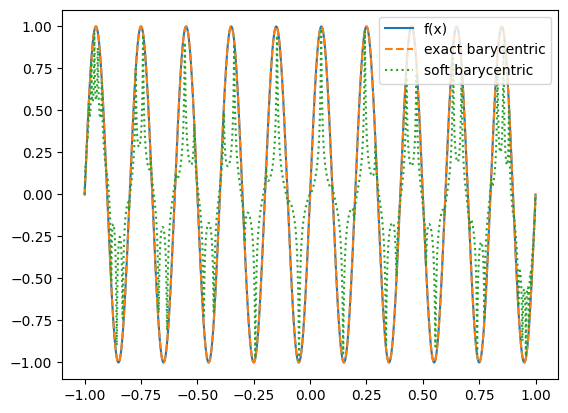

In [12]:
# barycentric_nnx.py
# Self-contained FP64 JAX + Flax NNX barycentric readout with exact and soft paths.

from __future__ import annotations
import math
from dataclasses import dataclass
import jax
import jax.numpy as jnp
from jax import jit, vmap
from flax import nnx

# Enable float64
jax.config.update("jax_enable_x64", True)

# -----------------------------
# Utilities: Chebyshev(2) nodes/weights and helpers
# -----------------------------

def cheb2_nodes(n: int) -> jnp.ndarray:
    """Chebyshev points of the second kind: x_j = cos(pi*j/n), j=0..n."""
    j = jnp.arange(n + 1, dtype=jnp.float64)
    return jnp.cos(jnp.pi * j / n)

def cheb2_weights(n: int) -> jnp.ndarray:
    """
    Barycentric weights for Chebyshev(2):
    w_j = (-1)^j * δ_j, where δ_0 = δ_n = 1/2, else 1.
    (Common overall constants cancel in the second barycentric form.)
    """
    j = jnp.arange(n + 1, dtype=jnp.float64)
    delta = jnp.ones_like(j)
    delta = delta.at[0].set(0.5).at[-1].set(0.5)
    signs = (-1.0) ** j
    return signs * delta

def _nearly_equal(a: jnp.ndarray, b: jnp.ndarray, tol: float = 0.0) -> jnp.ndarray:
    # Exact snap by default (tol=0.0): true if a == b in FP64
    return jnp.isclose(a, b, rtol=0.0, atol=tol)

# -----------------------------
# Exact second-barycentric evaluator (vectorized)
# -----------------------------

def barycentric_second_form(
    x: jnp.ndarray,
    xj: jnp.ndarray,
    fj: jnp.ndarray,
    wj: jnp.ndarray,
    snap_tol: float = 0.0,
) -> jnp.ndarray:
    """
    Exact second barycentric form with snap-to-node.
    Vectorized over x (arbitrary shape). Returns same shape as x.
    """
    x = jnp.asarray(x, dtype=jnp.float64)
    xj = jnp.asarray(xj, dtype=jnp.float64)
    fj = jnp.asarray(fj, dtype=jnp.float64)
    wj = jnp.asarray(wj, dtype=jnp.float64)

    def _eval_single(x_scalar: jnp.float64) -> jnp.float64:
        # Snap to data if x coincides with a node
        eq = _nearly_equal(x_scalar, xj, tol=snap_tol)
        any_eq = jnp.any(eq)
        def _snap():
            idx = jnp.argmax(eq)  # first match
            return fj[idx]
        def _ratio():
            d = x_scalar - xj  # signed
            terms = wj / d      # can be large; overall ratio is stable
            num = jnp.sum(terms * fj)
            den = jnp.sum(terms)
            return num / den
        return jax.lax.cond(any_eq, _snap, _ratio)

    return jax.vmap(_eval_single)(x.reshape(-1)).reshape(x.shape)

# -----------------------------
# Barycentric differentiation matrix (at nodes)
# D_ij = w_j/(w_i (x_i - x_j)) for i≠j, D_ii = -sum_{j≠i} D_ij
# -----------------------------

def barycentric_diff_matrix(xj: jnp.ndarray, wj: jnp.ndarray) -> jnp.ndarray:
    """
    First-derivative matrix at the nodes for the interpolant, standard barycentric form.
    """
    xj = jnp.asarray(xj, dtype=jnp.float64)
    wj = jnp.asarray(wj, dtype=jnp.float64)
    X = xj[:, None]
    dX = X - X.T
    # Off-diagonals:
    off = wj[None, :] / (wj[:, None] * dX + jnp.eye(xj.size))  # add eye to avoid /0 on diag
    off = off - jnp.diag(jnp.diag(off))  # zero the diagonals
    # Diagonals:
    diag = -jnp.sum(off, axis=1)
    D = off + jnp.diag(diag)
    return D

# -----------------------------
# Flax NNX Modules
# -----------------------------

class SignedBarycentric(nnx.Module):
    """
    Exact second barycentric readout (no trainable params by default).
    """
    def __init__(self, xj: jnp.ndarray, fj: jnp.ndarray, wj: jnp.ndarray, snap_tol: float = 0.0):
        self.xj = xj.astype(jnp.float64)
        self.fj = fj.astype(jnp.float64)
        self.wj = wj.astype(jnp.float64)
        self.snap_tol = float(snap_tol)

    def __call__(self, x: jnp.ndarray) -> jnp.ndarray:
        return barycentric_second_form(x, self.xj, self.fj, self.wj, self.snap_tol)

class SoftBarycentric(nnx.Module):
    """
    Value-space normalized 'soft barycentric' surrogate:
      alpha_j(x) ∝ exp(b_j - tau * log(|x - x_j| + eps))
      y = sum_j alpha_j(x) * f_j
    Trainable: tau (scalar), b (per-node). Initialized to tau=1, b_j=log|w_j|.
    """
    def __init__(self, rngs: nnx.Rngs, xj: jnp.ndarray, fj: jnp.ndarray, wj: jnp.ndarray,
                 eps: float = 1e-15, tau_init: float = 1.0):
        self.xj = xj.astype(jnp.float64)
        self.fj = fj.astype(jnp.float64)
        self.eps = float(eps)
        # params: tau, b
        self.tau = nnx.Param(jnp.array(tau_init, dtype=jnp.float64))
        # IMPORTANT: magnitude only inside log; signs are handled by SignedBarycentric exact path
        self.b = nnx.Param(jnp.log(jnp.abs(wj.astype(jnp.float64)) + 0.0))

    def __call__(self, x: jnp.ndarray) -> jnp.ndarray:
        x = jnp.asarray(x, dtype=jnp.float64)
        d = jnp.abs(x[..., None] - self.xj[None, ...]) + self.eps
        logits = self.b[None, ...] - self.tau * jnp.log(d)
        alpha = jax.nn.softmax(logits, axis=-1)
        return jnp.sum(alpha * self.fj[None, :], axis=-1)

class BarycentricReadout(nnx.Module):
    """
    Wrapper that exposes:
      - exact(x): exact second barycentric output (DEFAULT)
      - soft(x):  soft value-space surrogate output
      The module initializes to match the exact barycentric output.
    """
    def __init__(self, rngs: nnx.Rngs, xj: jnp.ndarray, fj: jnp.ndarray, wj: jnp.ndarray,
                 snap_tol: float = 0.0, soft_eps: float = 1e-15):
        self.exact_layer = SignedBarycentric(xj, fj, wj, snap_tol=snap_tol)
        self.soft_layer = SoftBarycentric(rngs, xj, fj, wj, eps=soft_eps, tau_init=1.0)

    def exact(self, x: jnp.ndarray) -> jnp.ndarray:
        return self.exact_layer(x)

    def soft(self, x: jnp.ndarray) -> jnp.ndarray:
        return self.soft_layer(x)

    # Default call == exact output (so the network is initialized to the exact interpolant)
    def __call__(self, x: jnp.ndarray) -> jnp.ndarray:
        return self.exact(x)

# -----------------------------
# Example usage / sanity checks
# -----------------------------

if __name__ == "__main__":
    key = jax.random.PRNGKey(0)
    n = 64
    xj = cheb2_nodes(n)                  # Chebyshev(2) nodes
    wj = cheb2_weights(n)                # Chebyshev(2) barycentric weights
    # target: f(x) = sin(2πk * ((x+1)/2)) on [-1,1]  (periodic in original x∈[0,1])
    k = 5
    def f_true(x): return jnp.sin(2.0 * jnp.pi * k * (x))
    fj = f_true(xj)

    # Build readout (initialized to exact)
    rngs = nnx.Rngs(key)
    net = BarycentricReadout(rngs, xj, fj, wj, snap_tol=0.0, soft_eps=1e-15)

    # Interpolation property at nodes (exact snap)
    recon_nodes = net(xj)
    node_err = jnp.max(jnp.abs(recon_nodes - fj))
    print("max |p(x_j)-f_j| =", float(node_err))  # should be 0 exactly with snap_tol=0.0

    # Evaluate on a dense grid
    xx = jnp.linspace(-1.0, 1.0, 2001, dtype=jnp.float64)
    pp_exact = net(xx)
    pp_soft  = net.soft(xx)

    # Compare to ground truth
    err_exact = jnp.max(jnp.abs(pp_exact - f_true(xx)))
    err_soft  = jnp.max(jnp.abs(pp_soft  - f_true(xx)))
    print("max error (exact path) =", float(err_exact))
    print("max error (soft  path) =", float(err_soft))

    # Differentiation at nodes via barycentric differentiation matrix
    D = barycentric_diff_matrix(xj, wj)
    pprime_at_nodes = D @ fj  # equals derivative of interpolant at nodes
    # For a true polynomial interpolant of analytic f, this is the nodal derivative of the degree-n interpolant.
    print("||p'(x_j)||_inf =", float(jnp.max(jnp.abs(pprime_at_nodes))))



    plt.plot(xx, f_true(xx), label="f(x)")
    plt.plot(xx, pp_exact, "--", label="exact barycentric")
    plt.plot(xx, pp_soft, ":", label="soft barycentric")
    plt.legend()
    plt.show()